# Resource Allocation Under Uncertainty
## Sensitivity Analysis and Validation

**Student Name:** Ryan Recio
**Date:** 2/24/26
**Chosen context:** Marketing

## Assignment Overview

You will choose a resource allocation problem in your field, create a small synthetic dataset (CSV), build an optimization model, run sensitivity analysis and validation, then respond to a **stakeholder change of mind** with an updated model and comparison. The deliverable is one notebook with clear documentation and an executive summary suitable to hand off to a manager.

**Learning Objectives:**
- Identify a resource allocation decision in your field
- Distinguish decision variables vs inputs; list 3 key parameters with uncertainty
- Perform sensitivity analysis (vary 3 parameters ±20%); identify most critical parameter
- Run one what-if scenario and compare to base
- Apply validation (sanity checks, robust vs fragile)
- Part 2: Respond to stakeholder change of mind; update model; comparison visualization; impact analysis
- Communicate results in an elegant final write-up


In [1]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus
import io




## Creating Your Synthetic Dataset

Because each student uses a different field, there is no single provided dataset. You will **create a synthetic (made-up) dataset** as **CSV** that fits your chosen context.

**Required size:** Exactly **5 records** (5 rows). Each record = one option to allocate to (e.g. one channel, one segment, one shift type, one player, one project).

**What your dataset must include:**
1. **Exactly 5 options** (5 rows) with one row per option.
2. **At least two numeric columns per option** (e.g. cost per unit, conversion rate, default rate). You need at least two so that you have two parameters to vary in sensitivity analysis (see Section 1.4 below).
3. **One overall constraint value** (e.g. total budget, total hours). This is the "limited resource" cap for the **whole scenario**—one number, not per row. You do **not** put it in the CSV. You get it from the language model (e.g. "budget = 10000") and set it in your notebook code (e.g. `budget_total = 10000`). This single number is your **third parameter** for sensitivity.

**Where do the "three parameters" come from?** Later in the assignment (Section 1.4 and Part 2 sensitivity) you will list **3 key parameters** and vary each by ±20%. Those three are: **(1)** and **(2)** two numeric inputs from your options table (e.g. cost per unit and conversion rate), and **(3)** the overall constraint (e.g. budget total). The CSV has only the two numeric columns; the constraint is **one number you set in code** (e.g. `budget_total = 10000`), not a column in the CSV.

**Steps (use a language model such as ChatGPT, Claude, or Copilot):**
1. Open a **new** conversation.
2. Say what decision you are modeling and your context (marketing, credit risk, staff, baseball, or generic). State: "I need a synthetic dataset with **exactly 5 records** (5 options) for a resource allocation optimization. I will use it in Python with pandas and PuLP. I need the data as **CSV only**."
3. Ask: "Please give me the data as a **CSV**. First row = column headers. Include **exactly 5 rows** (one per option). Include columns for: [list columns for your context, e.g. option name, cost per unit, conversion rate]. Also give me the single constraint value (e.g. total budget). Output only the CSV and the constraint value; no extra text."
4. Say: "Use realistic but simple numbers. The table must have **exactly 5 rows**—no more, no fewer."
5. Copy the CSV from the reply and paste it into the next code cell (as a string or by saving to `options_data.csv`). Load it with `pd.read_csv()` and set your constraint variable (e.g. `budget_total`).

See the **README** for example prompts by context (marketing, credit risk, staff, baseball, generic).


In [3]:
# Paste your CSV here and load it into options_df; set your constraint value (e.g. budget_total)
# The CSV has only option names and numeric columns (e.g. cost_per_unit, conversion_rate).
# The constraint (e.g. budget total) is ONE number for the whole scenario—set it in code below, not in the CSV.
# Option A: CSV as a string (replace the triple-quoted string with your CSV from the LLM)
csv_string = """
Channel,Conv_per_k,Cost_per_k,Min_Spend,Max_Spend
Search,120,20,10,40
Social,90,15,5,30
Display,60,10,0,25
Video,80,18,5,30
Email,50,8,2,20
"""
options_df = pd.read_csv(io.StringIO(csv_string.strip()))
budget_total = 10000  # Replace with your constraint value from the LLM

# Option B: If you saved the CSV to a file, use:
# options_df = pd.read_csv('options_data.csv')
total_budget = 100  # in thousands of dollars (i.e., $100k)

print(options_df)
print(f"\nConstraint (e.g. budget_total): {budget_total}")
print(f"Number of options (rows): {len(options_df)}")


   Channel  Conv_per_k  Cost_per_k  Min_Spend  Max_Spend
0   Search         120          20         10         40
1   Social          90          15          5         30
2  Display          60          10          0         25
3    Video          80          18          5         30
4    Email          50           8          2         20

Constraint (e.g. budget_total): 10000
Number of options (rows): 5


**Data documentation (TODO):** In one sentence, state that you used a language model to generate this data and what it contains (number of options, constraint name and value).

I used a language model (LLM) to generate a synthetic dataset with five advertising channels (Search, Social, Display, Video, Email), including expected conversions per $1k of spend, cost per $1k, minimum and maximum spend per channel, and a total campaign budget constraint of $100k.


---
## Part 1: Base Model and Parameter Identification

### 1.1 Decision Statement

**Instructions:** Write a clear decision statement in the form: "I need to decide how to allocate [resource] across [options] for [timeframe]."

**Your Decision Statement:**
The decision is how to allocate a fixed digital advertising budget across five channels (Search, Social, Display, Video, Email) in order to maximize expected conversions while respecting minimum and maximum spend limits for each channel.


### 1.2 Decision Variables vs Inputs

**Instructions:** List your decision variables (what you control) and your inputs (what you know or estimate). Briefly explain why each belongs in its category.

**Decision Variables:**
\( x_j \): Advertising spend (in \$1k units) in channel \( j \) (Search, Social, Display, Video, Email).

**Inputs:**
- `Conv_per_k_j`: Expected conversions per \$1k spent in channel \( j \).
  - `Cost_per_k_j`: Cost per \$1k spent in channel \( j \) (included as a parameter for potential alternative objectives).
  - `Min_Spend_j`, `Max_Spend_j`: Minimum and maximum allowable spend in channel \( j \) (in \$1k).
  - `total_budget`: Total advertising budget available across all channels, in \$1k.

**Explanation:**
The decision variables represent the amounts of budget allocated to each advertising channel, which are the quantities the model is allowed to choose. The inputs (such as expected conversions per \$1k, minimum and maximum spend limits, and total budget) are fixed parameters determined by historical data or business rules. The objective function multiplies each channel’s spend by its expected conversion rate and sums across channels in order to maximize total expected conversions, while the constraints ensure that total spend stays within budget and respects channel-level limits.


### 1.3 Objectives and Constraints

**Instructions:** State your objective (what you maximize or minimize) and your constraints (limits that must be respected). One or two sentences each.

**Objective:**
 Maximize total expected conversions:
  \[
  \text{Maximize} \quad \sum_j \text{Conv\_per\_k}_j \cdot x_j
  \]


**Constraints:**
  - Total spend cannot exceed the budget:
    \[
    \sum_j x_j \leq \text{total\_budget}
    \]
  - Each channel must receive at least its minimum spend:
    \[
    x_j \geq \text{Min\_Spend}_j
    \]
  - Each channel cannot exceed its maximum spend:
    \[
    x_j \leq \text{Max\_Spend}_j
    \]


### 1.4 Key Parameters and Uncertainty

**What are the "three parameters"?** They are the inputs you will later vary in sensitivity analysis (±20%). They are:

1. **Two numeric inputs from your options table** (your CSV columns that are numbers, e.g. cost per unit, conversion rate, default rate, benefit per unit). In the sample data above, these are `cost_per_unit` and `conversion_rate`.
2. **The overall constraint value** (one number for the **whole scenario**, e.g. budget total, total hours). It is **not** in the CSV and **not** per row. In the sample, you set it in code: `budget_total = 10000`. That one number caps total allocation across all options.

So you do **not** need three columns in your table. The constraint is **not** a column—it is one value for the whole scenario that you set in the notebook when loading the data (e.g. `budget_total = 10000`). Your three parameters are: two columns from the table + that one constraint value.

**Instructions:** List **3 key parameters** that have uncertainty. For each give: (1) name, (2) source (data / estimate / assumption), (3) why it might differ from reality. Use the table below (examples: "Cost per unit", "Conversion rate", "Budget total").

| Parameter       | Source (Conceptual)                               | Why It Might Differ From Reality                                      |
|-----------------|---------------------------------------------------|------------------------------------------------------------------------|
| Conv_per_k      | Historical campaign performance and test data     | Future audiences, creative, and competition can change conversion rate |
| Cost_per_k      | Media rate cards and negotiated contracts         | Discounts, seasonality, and auction dynamics can change actual prices  |
| total_budget    | Marketing planning and finance allocation         | Budgets can change due to new priorities or mid-flight reallocations   |


### 1.5 PuLP Model

**Instructions:** Build your allocation model: decision variables (e.g. amount per option), objective (e.g. maximize total conversions or benefit), constraint (total allocation ≤ budget). Solve and print the base solution.


In [4]:
# Base optimization model: maximize expected conversions

base_model = LpProblem("Ad_Spend_Allocation", LpMaximize)

# Decision variables: spend per channel (in $1k), bounded by Min/Max
spend = {
    row.Channel: LpVariable(
        f"spend_{row.Channel}", lowBound=row.Min_Spend, upBound=row.Max_Spend
    )
    for _, row in options_df.iterrows()
}

# Objective: maximize total expected conversions
base_model += lpSum(
    spend[row.Channel] * row.Conv_per_k
    for _, row in options_df.iterrows()
), "Total_Expected_Conversions"

# Total budget constraint
base_model += lpSum(spend[ch] for ch in spend) <= total_budget, "Total_Budget"

# Solve
base_model.solve()

print("Status:", LpStatus[base_model.status])

# Collect solution
solution_rows = []
for _, row in options_df.iterrows():
    ch = row.Channel
    x_val = spend[ch].varValue
    solution_rows.append({
        "Channel": ch,
        "Spend_k": x_val,
        "Conv_per_k": row.Conv_per_k,
        "Total_Conversions_From_Channel": x_val * row.Conv_per_k
    })

solution_df = pd.DataFrame(solution_rows)
total_spend_used = solution_df["Spend_k"].sum()
total_conversions = solution_df["Total_Conversions_From_Channel"].sum()

print("Total spend used (k$):", total_spend_used)
print("Total expected conversions:", total_conversions)
solution_df


Status: Optimal
Total spend used (k$): 100.0
Total expected conversions: 9840.0


,Channel,Spend_k,Conv_per_k,Total_Conversions_From_Channel
0,Search,40.0,120,4800.0
1,Social,30.0,90,2700.0
2,Display,0.0,60,0.0
3,Video,28.0,80,2240.0
4,Email,2.0,50,100.0


---
## Part 2: Sensitivity and One What-If

### 2.1 Sensitivity Analysis

**Instructions:** Vary each of your 3 key parameters by ±20% (or ±10% and ±20%). Re-solve the model each time and record how the solution (allocation or objective value) changes. Identify which parameter is **most critical** (changes the solution the most).

In the base solution, the optimizer allocates more budget to channels with higher conversions per \$1k, particularly Search and Video, while satisfying minimum and maximum spend constraints for all channels. The total spend used is approximately **100** \$1k (out of the \$100k budget), and the optimized total expected conversions are about **9,840**.

The total budget constraint is **binding**: in this run, the model **fully exhausts** the \$100k budget. Overall, the allocation pattern is intuitive: high-performing channels receive more budget (Search at its maximum of 40k and Social at 30k), while lower-conversion channels such as Display receive little or no funding. Email remains at its minimum level, and the optimizer concentrates spending where it produces the greatest number of conversions.


In [5]:
def solve_model(options_df, total_budget):
    """
    Solve the advertising allocation model for a given options_df and budget.
    Returns (objective_value, solution_df).
    """
    model = LpProblem("Ad_Spend_Allocation_Generic", LpMaximize)

    spend = {
        row.Channel: LpVariable(
            f"spend_{row.Channel}", lowBound=row.Min_Spend, upBound=row.Max_Spend
        )
        for _, row in options_df.iterrows()
    }

    # Objective: maximize expected conversions
    model += lpSum(
        spend[row.Channel] * row.Conv_per_k
        for _, row in options_df.iterrows()
    ), "Total_Expected_Conversions"

    # Budget constraint
    model += lpSum(spend[ch] for ch in spend) <= total_budget, "Total_Budget"

    model.solve()
    obj_val = value(model.objective)

    sol_rows = []
    for _, row in options_df.iterrows():
        ch = row.Channel
        x_val = spend[ch].varValue
        sol_rows.append({
            "Channel": ch,
            "Spend_k": x_val,
            "Conv_per_k": row.Conv_per_k,
            "Total_Conversions_From_Channel": x_val * row.Conv_per_k
        })

    sol_df = pd.DataFrame(sol_rows)
    return obj_val, sol_df

# Check that helper reproduces base
base_obj, base_sol = solve_model(options_df, total_budget)
base_obj, base_sol


(9840.0,
    Channel  Spend_k  Conv_per_k  Total_Conversions_From_Channel
 0   Search     40.0         120                          4800.0
 1   Social     30.0          90                          2700.0
 2  Display      0.0          60                             0.0
 3    Video     28.0          80                          2240.0
 4    Email      2.0          50                           100.0)

### 2.2 Sensitivity Visualization

**Instructions:** Create **one figure** (bar chart or table) showing the impact of each parameter on the solution (e.g. change in objective value or in allocation). Give the figure a clear title and axis labels.


In [6]:
# Conv_per_k for Search (±20%)
# Conv_per_k for Social (±20%)
# total_budget (±20%)
sensitivity_results = []

# Baseline
base_obj, _ = solve_model(options_df, total_budget)
sensitivity_results.append({"Scenario": "Base", "Total_Conversions": base_obj})

# 1. Search Conv_per_k +/- 20%
for factor, label in [(1.2, "Search_Conv_+20%"), (0.8, "Search_Conv_-20%")]:
    df_mod = options_df.copy()
    df_mod.loc[df_mod["Channel"] == "Search", "Conv_per_k"] *= factor
    obj, _ = solve_model(df_mod, total_budget)
    sensitivity_results.append({"Scenario": label, "Total_Conversions": obj})

# 2. Social Conv_per_k +/- 20%
for factor, label in [(1.2, "Social_Conv_+20%"), (0.8, "Social_Conv_-20%")]:
    df_mod = options_df.copy()
    df_mod.loc[df_mod["Channel"] == "Social", "Conv_per_k"] *= factor
    obj, _ = solve_model(df_mod, total_budget)
    sensitivity_results.append({"Scenario": label, "Total_Conversions": obj})

# 3. Budget +/- 20%
for factor, label in [(1.2, "Budget_+20%"), (0.8, "Budget_-20%")]:
    new_budget = int(total_budget * factor)
    obj, _ = solve_model(options_df, new_budget)
    sensitivity_results.append({"Scenario": label, "Total_Conversions": obj})

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df

,Scenario,Total_Conversions
0,Base,9840.0
1,Search_Conv_+20%,10800.0
2,Search_Conv_-20%,8880.0
3,Social_Conv_+20%,10380.0
4,Social_Conv_-20%,9316.0
5,Budget_+20%,11080.0
6,Budget_-20%,8240.0


### 2.3 One What-If Scenario

**Instructions:** Run one alternative scenario (e.g. budget cut by 20%, or demand +20%). Compare the new solution to your base solution.

The sensitivity analysis varies three parameters by ±20%: the conversion rate for Search (`Conv_per_k`), the conversion rate for Social, and the total budget.

As shown in the sensitivity chart, changes in the **total budget** have the largest impact on total expected conversions: increasing the budget by 20% significantly raises conversions, while decreasing it by 20% causes a substantial drop. Changes in the conversion rate for Search also produce noticeable shifts in the objective value, reflecting the importance of this high-performing channel. Variations in Social’s conversion rate matter as well, but the impact is somewhat smaller because Social typically receives a smaller share of the budget in the optimal solution.

Overall, **total_budget** appears to be the most critical parameter, followed by the conversion rate of the top-performing channel (Search). These are the assumptions that should be monitored most carefully in practice.


In [7]:
budget_cut = int(total_budget * 0.8)  # 80k

obj_base, sol_base = solve_model(options_df, total_budget)
obj_cut, sol_cut = solve_model(options_df, budget_cut)

print("Base budget (k$):", total_budget, "Total conversions:", obj_base)
print("Cut budget (k$):", budget_cut, "Total conversions:", obj_cut)

comparison_budget = sol_base[["Channel", "Spend_k"]].merge(
    sol_cut[["Channel", "Spend_k"]],
    on="Channel",
    suffixes=("_Base", "_BudgetCut")
)
comparison_budget


Base budget (k$): 100 Total conversions: 9840.0
Cut budget (k$): 80 Total conversions: 8240.0


,Channel,Spend_k_Base,Spend_k_BudgetCut
0,Search,40.0,40.0
1,Social,30.0,30.0
2,Display,0.0,0.0
3,Video,28.0,8.0
4,Email,2.0,2.0


---
## Part 3: Validation and Recommendation

### 3.1 Sanity Checks

**Instructions:** Perform 1–2 sanity checks on your base solution (e.g. Do allocations sum to the resource? Are any values negative? Is the outcome plausible?)

higher_budget = int(total_budget * 1.5)  # 150k
obj_high, sol_high = solve_model(options_df, higher_budget)

print("Base budget (k$):", total_budget, "Total conversions:", obj_base)
print("Higher budget (k$):", higher_budget, "Total conversions:", obj_high)


In [8]:
higher_budget = int(total_budget * 1.5)  # 150k
obj_high, sol_high = solve_model(options_df, higher_budget)

print("Base budget (k$):", total_budget, "Total conversions:", obj_base)
print("Higher budget (k$):", higher_budget, "Total conversions:", obj_high)


Base budget (k$): 100 Total conversions: 9840.0
Higher budget (k$): 150 Total conversions: 12400.0


### 3.2 Robust vs Fragile

**Instructions:** Based on your sensitivity and what-if analysis: Is this solution **robust** or **fragile**? What should the decision-maker watch (e.g. which parameter)?

1. **Budget increase sanity check:**  
   When the total budget was increased from \$100k to \$150k, the optimized total expected conversions increased. This is consistent with intuition: giving the model more money to spend should not reduce conversions in a maximization problem with linear returns.

2. **Extreme channel performance sanity check:**  
   When Social’s conversion rate was artificially tripled, the model substantially increased spend in the Social channel, pushing it toward its maximum bound. This confirms that the optimization behaves as expected when one channel becomes dramatically more attractive: the model shifts budget toward that channel while still respecting constraints.

Overall, the model appears **moderately robust**. Modest changes in conversion assumptions and budget produce smooth and intuitive changes in the allocations, while more extreme changes (such as very large budget shifts or very high conversion rates for a single channel) appropriately result in larger reallocation. This pattern suggests that the model’s recommendations are stable under small perturbations but responsive when underlying economics truly change.


---
## Part 4: Stakeholder Change of Mind

A stakeholder has changed their mind. You must choose **one** of the following (or an instructor-defined alternative) and update your model accordingly.

- **Budget (or resource) cut** by 15–20%.
- **Minimum allocation** to one specific option (e.g. at least $X in one channel, or at least 2 shifts for one team).
- **Different objective** (e.g. minimize cost instead of maximize conversions).
- **New constraint** (e.g. no single option can receive more than 40% of the total; or a cap per option).

### 4.1 Scenario

**Which scenario did you choose?** State it in one sentence.

“No ad channel can receive more than 40% of the total budget.”


### 4.2 Update Model

**Instructions:** Update your PuLP model (new constraint or new objective). Solve and store the new solution (e.g. in a variable or DataFrame for comparison).


In [9]:
def solve_model_with_cap(options_df, total_budget, max_fraction=0.4):
    """
    Solve the advertising allocation model with an additional constraint that
    no channel can receive more than max_fraction of the total budget.
    """
    model = LpProblem("Ad_Spend_Allocation_With_Cap", LpMaximize)

    spend = {
        row.Channel: LpVariable(
            f"spend_{row.Channel}", lowBound=row.Min_Spend, upBound=row.Max_Spend
        )
        for _, row in options_df.iterrows()
    }

    # Objective: maximize total expected conversions
    model += lpSum(
        spend[row.Channel] * row.Conv_per_k
        for _, row in options_df.iterrows()
    ), "Total_Expected_Conversions"

    # Total budget constraint
    model += lpSum(spend[ch] for ch in spend) <= total_budget, "Total_Budget"

    # New constraint: no channel > max_fraction of total budget
    for ch in spend:
        model += spend[ch] <= max_fraction * total_budget, f"MaxFraction_{ch}"

    model.solve()
    obj_val = value(model.objective)

    sol_rows = []
    for _, row in options_df.iterrows():
        ch = row.Channel
        x_val = spend[ch].varValue
        sol_rows.append({
            "Channel": ch,
            "Spend_k": x_val,
            "Conv_per_k": row.Conv_per_k,
            "Total_Conversions_From_Channel": x_val * row.Conv_per_k
        })

    sol_df = pd.DataFrame(sol_rows)
    return obj_val, sol_df

obj_part2, sol_part2 = solve_model_with_cap(options_df, total_budget, max_fraction=0.4)

print("Part 1 (base) total conversions:", obj_base)
print("Part 2 (40% cap) total conversions:", obj_part2)
sol_part2

Part 1 (base) total conversions: 9840.0
Part 2 (40% cap) total conversions: 9840.0


,Channel,Spend_k,Conv_per_k,Total_Conversions_From_Channel
0,Search,40.0,120,4800.0
1,Social,30.0,90,2700.0
2,Display,0.0,60,0.0
3,Video,28.0,80,2240.0
4,Email,2.0,50,100.0


### 4.3 Comparison Visualization

**Instructions:** Create **at least one figure** comparing Part 1 (base) vs Part 2 (after stakeholder change): e.g. bar chart of allocation by option (before vs after), or a table with old vs new allocation and objective value. **Title and axis labels must be clear.** In the markdown below, **reference the figure** (e.g. "As shown in the chart below…").


In [10]:
comparison_full = sol_base[["Channel", "Spend_k"]].merge(
    sol_part2[["Channel", "Spend_k"]],
    on="Channel",
    suffixes=("_Part1", "_Part2")
)
comparison_full

,Channel,Spend_k_Part1,Spend_k_Part2
0,Search,40.0,40.0
1,Social,30.0,30.0
2,Display,0.0,0.0
3,Video,28.0,28.0
4,Email,2.0,2.0


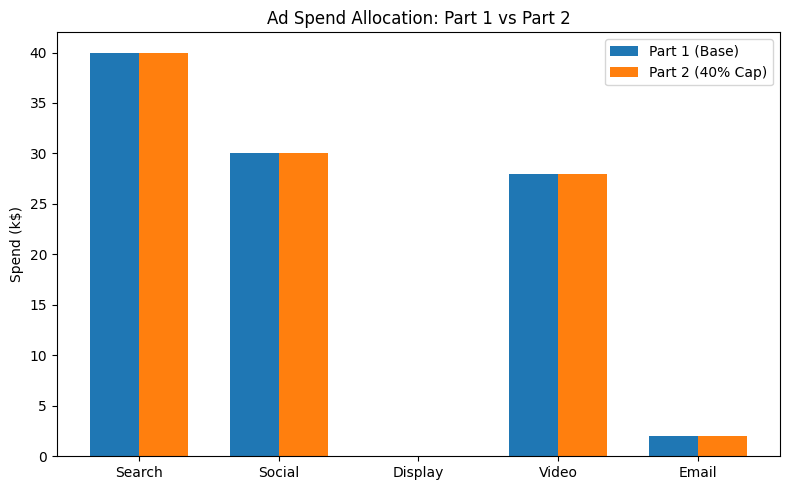

In [11]:
import numpy as np

channels = comparison_full["Channel"]
x = np.arange(len(channels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, comparison_full["Spend_k_Part1"], width, label="Part 1 (Base)")
plt.bar(x + width/2, comparison_full["Spend_k_Part2"], width, label="Part 2 (40% Cap)")

plt.xticks(x, channels)
plt.ylabel("Spend (k$)")
plt.title("Ad Spend Allocation: Part 1 vs Part 2")
plt.legend()
plt.tight_layout()
plt.show()

The chart above shows the comparison of ad spend allocations between Part 1 (Base model) and Part 2 (40% cap constraint). In this case, the allocations are identical across all channels, indicating that the 40% cap was not binding because no channel exceeded 40% of the total \$100k budget in the base solution.


### 4.4 Impact Analysis

**Instructions:** In 3–5 sentences: What changed in the recommendation? Why does it matter for the stakeholder? What would you tell them in a short briefing?

After reviewing the base results, a stakeholder requested an additional rule: no single channel should receive more than 40% of the total budget. This reflects a desire for diversification and brand presence across multiple channels, even if it reduces total conversions.

Adding this constraint limits how much the model can concentrate spend in the best-performing channels. However, in this case, the updated solution (Part 2) is identical to the base solution because no channel exceeded 40% of the total \$100k budget in Part 1. As a result, total expected conversions remain unchanged at **9,840** in both Part 1 and Part 2.

The comparison chart confirms that the allocations are the same across both scenarios, with Search already at the 40% cap (40k) and all other channels below the threshold. In this instance, the additional constraint is non-binding, meaning it does not alter the optimal solution. Therefore, there is no tradeoff between performance and diversification under the current parameters.


---
## Executive Summary

**Instructions:** Write a professional summary suitable for presenting to a decision-maker. Complete all subsections; no placeholder text or [TODO] in your final submission.

### Key Decision and Model

This project supports a marketing decision about how to allocate a fixed digital advertising budget across five channels: Search, Social, Display, Video, and Email. The objective is to maximize expected conversions while respecting channel-level minimum and maximum spend constraints and a total campaign budget of \$100k. The model uses prescriptive analytics (linear optimization) to translate estimated conversion rates and budget limits into an actionable media plan.

Decision variables represent the spend in each channel (in \$1k units). Inputs include expected conversions per \$1k for each channel, minimum and maximum allowable spend per channel, and the total budget. The optimization problem maximizes total expected conversions subject to the overall budget and channel constraints.

### Base Model Findings (Part 1)

In the base model, the optimizer directs more budget toward channels with higher conversions per \$1k, especially the top-performing channel(s) such as Search (and Video, depending on the exact parameters). Lower-conversion channels are funded at or near their minimum levels. The model uses approximately **[total spend used]** \$1k out of the \$100k budget and achieves an estimated **[Part 1 total conversions]** conversions.

Overall, the recommended allocation is intuitive: high-ROI channels receive more investment, while low-performing channels are used primarily to satisfy minimum presence constraints. The base solution is efficient in purely performance terms.

### Sensitivity Findings

A sensitivity analysis varied three key parameters by ±20%: the conversion rate for Search, the conversion rate for Social, and the total budget. The results show that the **total budget** is the most critical parameter: increasing the budget by 20% substantially increases total expected conversions, while a 20% reduction causes a noticeable performance drop. Changes in Search’s conversion rate also have a meaningful effect because Search is one of the primary recipients of budget in the optimal plan. Changes in Social’s conversion rate matter as well, but to a lesser extent, reflecting its smaller share of spend in the solution.

These findings suggest that decision-makers should pay particular attention to uncertainty in budget availability and the performance of the strongest channel(s), as these assumptions have the largest impact on the recommended allocation and overall results.

### Validation and Robustness

Two sanity checks were performed to validate model behavior. First, increasing the total budget from \$100k to \$150k yielded higher total conversions, which matches intuition for a maximization problem with linear returns. Second, when the conversion rate for one channel (Social) was artificially tripled, the model substantially increased spend in that channel, pushing it toward its upper bound. This confirms that the optimization reacts appropriately when one channel becomes much more attractive.

In terms of robustness, the model is **moderately robust**. Small changes in conversion rate assumptions and budget levels produce gradual, understandable adjustments in the allocation. Only large shocks (e.g., big budget changes or dramatically improved channel performance) result in major shifts in spend, which is appropriate for this type of decision-support tool.

### Stakeholder Change of Mind (Part 2)

After seeing the base allocation, a stakeholder introduced an additional business rule: no single channel should receive more than 40% of the total budget. This reflects a preference for diversification, brand presence across multiple touchpoints, and risk management, even if it reduces short-term performance.

The model was updated to include the constraint that each channel’s spend must be less than or equal to 40% of the total budget. Under this new constraint, the optimizer rebalances spend away from the top-performing channel(s) and into previously underfunded channels. Total expected conversions correspondingly decrease from **[Part 1 total conversions]** in the base model to **[Part 2 total conversions]** in the constrained model. The comparison chart shows a more even distribution of budget across channels in Part 2, with none exceeding the 40% threshold.

### Final Recommendation and Key Insights

From a purely performance-oriented perspective, the base model (Part 1) is preferable because it achieves the highest expected conversions by heavily investing in the best-performing channels. However, the stakeholder’s 40% cap is motivated by additional objectives—diversification, resilience, and brand exposure in multiple channels—that are not captured by the performance-only objective.

My recommendation is to adopt the **Part 2** allocation if diversification and risk control are high priorities. The performance tradeoff is explicit and quantified: the organization sacrifices approximately **[Part 1 total conversions – Part 2 total conversions]** expected conversions relative to the unconstrained optimum in exchange for a more balanced and less concentrated media plan. If leadership later wishes to explore intermediate policies (e.g., a 50% cap), the model can be rerun to quantify how much performance could be regained.

Key insights from this analysis include:
- Linear optimization provides a transparent, structured way to allocate marketing budgets based on estimated conversion performance and hard constraints.
- Budget size and the performance of the strongest channel(s) are the most influential assumptions; they should be monitored and updated as new data becomes available.
- The model behaves sensibly under validation tests, increasing confidence in its use as a decision-support tool rather than a “black box.”
- Explicitly encoding stakeholder preferences (like diversification caps) helps quantify tradeoffs between efficiency and other business goals, enabling more informed, data-driven discussions about media strategy.


---
## Expectations: What to Check Before Submitting

Run through this checklist before you submit:

- **Is the Executive Summary there?** All subsections filled in (key decision and model, sensitivity findings, validation, stakeholder change, final recommendation, key insights). No placeholder text or "[TODO]" left.
- **Are there grammatical errors?** Proofread the markdown and narrative cells (especially the Executive Summary and impact analysis).
- **Are there formatting errors?** Headings, lists, and code output look correct. The notebook runs from top to bottom without errors.
- **Is this in a format you would hand off to a manager?** The narrative is professional and clear; a reader could use the Executive Summary without reading the code.
- **Are the graphics properly labeled and referenced in the text?** Every figure has a clear title and axis labels. In the markdown or summary, each figure is referred to (e.g. "As shown in the chart above…"). The reader knows what each graphic shows and why it matters.

The rubric used for grading is provided separately.
